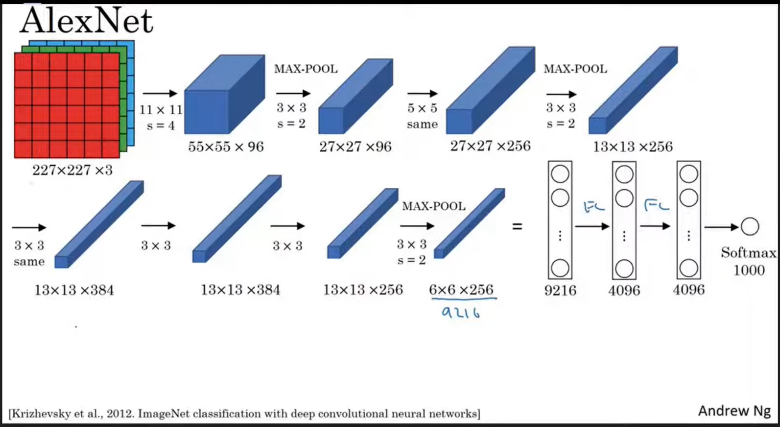



---

## 🌍 1. What is a Pretrained Model?

### ✅ Simple Definition:
> A **pretrained model** is a deep neural network that has already been trained on a **huge dataset** (like ImageNet) to recognize objects.

You don’t train it from scratch — you **use it as a starting point** for your own problem.

---

### 🧠 Example:
Imagine you’re learning to identify cats.

Instead of teaching yourself from zero, someone gives you a book with **10 million labeled animal photos** — and says:  
> "Here’s what I learned about animals. Now learn just about cats."

That’s what a **pretrained model** does.

---

## 🔁 2. How Did Pretrained Models Come Into Existence?

### ⏳ Before 2012: The Problem

- Training CNNs was **impossible** without massive data and compute
- Researchers tried small networks → poor accuracy
- No one could train deep networks effectively

### 💥 2012: AlexNet Changes Everything

> **AlexNet** (by Alex Krizhevsky, Ilya Sutskever, Geoffrey Hinton) won the **ImageNet competition** in 2012.

It achieved **84% accuracy** — beating traditional methods by **10+ points**.

This was the **birth of deep learning**.

---

## 🚀 3. Why Was AlexNet So Revolutionary?

Let’s break down why it changed the world:

| Feature | Why It Mattered |
|--------|------------------|
| ✅ **Deep Network** | 8 layers — deeper than anything before |
| ✅ **GPU Training** | Used 2 GPUs → made training possible |
| ✅ **ReLU Activation** | Faster than sigmoid/tanh |
| ✅ **Dropout** | Prevented overfitting |
| ✅ **Data Augmentation** | Rotated, flipped images → more robust |
| ✅ **Large Dataset** | Trained on 1.2M images (ImageNet) |

> 📈 Result: **Accuracy jumped** from ~75% to **84%** — a huge leap.

---

## 🎯 4. Why Do We Need Pretrained Models?

### ❌ Without Pretrained Models:
- You need **millions of labeled images**
- You need **massive compute** (GPUs, weeks of training)
- You risk **overfitting** on small datasets

### ✅ With Pretrained Models:
- Start with knowledge from **ImageNet** (1000 classes)
- Fine-tune on your **small dataset** (e.g., 100 cat/dog images)
- Get **better results faster**

> 🛠️ This is called **transfer learning**.

---

## 🔧 5. How Does Transfer Learning Work?

```python
# Step 1: Load pretrained model (e.g., ResNet50)
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',  # pre-trained on ImageNet
    include_top=False,   # remove last layer
    input_shape=(224, 224, 3)
)

# Step 2: Freeze base layers (don't update during training)
base_model.trainable = False

# Step 3: Add your own classifier
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary
])

# Step 4: Train only new layers
model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(train_ds, epochs=10)
```

> ✅ This trains fast, uses less data, and works well.

---

## 🧩 6. Challenges Before AlexNet

| Challenge | Why It Was Hard |
|---------|------------------|
| 🔹 No big datasets | No ImageNet → no scale |
| 🔹 Slow computers | CPUs too slow for deep nets |
| 🔹 Bad activations | Sigmoid/tanh caused vanishing gradients |
| 🔹 Overfitting | Small datasets → models memorized |
| 🔹 No good frameworks | No TensorFlow/PyTorch back then |

> 🧱 Deep learning was stuck — until **AlexNet** broke the wall.

---

## 🌐 7. What Changed After AlexNet?

AlexNet sparked a **revolution**:

| Year | Event |
|------|-------|
| 2012 | AlexNet wins ImageNet → deep learning starts |
| 2014 | VGG → simpler, deeper |
| 2015 | ResNet → skip connections → very deep nets |
| 2016 | Inception → efficient architecture |
| 2017 | Transformers → NLP revolution |
| 2020 | Vision Transformers (ViT) → CNNs not needed? |

> 🌪️ All these models started with **pretrained weights**.

---

## 🔄 8. How Are Pretrained Models Used Today?

| Use Case | Example |
|--------|--------|
| 🖼️ Image Classification | Detect cats in pet photos |
| 📸 Object Detection | Find cars in self-driving cars |
| 🎨 Style Transfer | Turn photo into Van Gogh |
| 🤖 Medical Imaging | Spot tumors in X-rays |
| 🗄️ Video Analysis | Detect people in surveillance |

> All use **pretrained models + fine-tuning**.

---

## 🧠 9. Key Takeaways (Summary)

| Concept | Meaning |
|--------|--------|
| **AlexNet** | First deep CNN to win ImageNet → birth of deep learning |
| **Pretrained Models** | Networks trained on ImageNet → use them for your task |
| **Transfer Learning** | Reuse knowledge from big data → solve small problems |
| **Why It Matters** | Saves time, money, data, and compute |
| **Modern Tools** | Use `tf.keras.applications` or `Hugging Face` |

---

## 🎯 Final Thought

> **AlexNet didn't just win a competition — it changed how we think about AI.**

Before: “Can machines see?”  
After: “Yes — and they can learn from billions of images.”

Now, **anyone** can build an AI model using pretrained weights — even with a laptop.

---



#Code

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, ReLU
from tensorflow.keras import Model

print("Using TensorFlow:", tf.__version__)

Using TensorFlow: 2.19.0


In [2]:
def make_alexnet(num_classes=1000):
    # Input layer
    inputs = Input(shape=(227, 227, 3))

    # Block 1: Conv + ReLU + Pool
    x = Conv2D(96, 11, strides=4, padding='valid')(inputs)
    x = ReLU()(x)
    x = MaxPooling2D(3, strides=2)(x)

    # Block 2: Conv + ReLU + Pool
    x = Conv2D(256, 5, padding='same')(x)
    x = ReLU()(x)
    x = MaxPooling2D(3, strides=2)(x)

    # Block 3: Conv + ReLU
    x = Conv2D(384, 3, padding='same')(x)
    x = ReLU()(x)

    # Block 4: Conv + ReLU
    x = Conv2D(384, 3, padding='same')(x)
    x = ReLU()(x)

    # Block 5: Conv + ReLU + Pool
    x = Conv2D(256, 3, padding='same')(x)
    x = ReLU()(x)
    x = MaxPooling2D(3, strides=2)(x)

    # Classifier
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs, outputs, name="AlexNet")
    return model

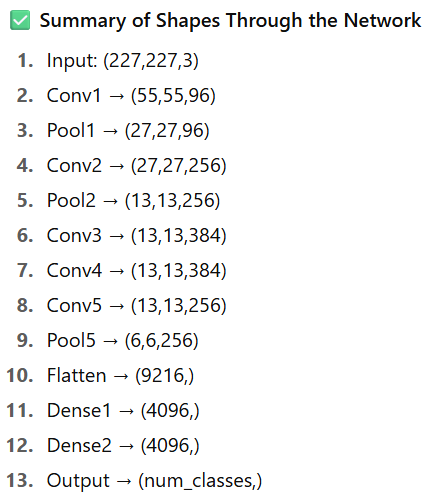

In [3]:
# Build model
model = make_alexnet(num_classes=1000)

# Compile (optional)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print summary
model.summary()

Model: "AlexNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 227, 227, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
import numpy as np

# Fake batch of 2 images
x = np.random.random((2, 227, 227, 3))

# Get predictions
preds = model(x)
print("Output shape:", preds.shape)  # (2, 1000)

Output shape: (2, 1000)



---

# 🔹 1. **Padding**

Padding = how we treat borders of the input image when applying convolution filters.

### Options in Keras (`Conv2D`)

* **`padding='valid'`**
  → No padding, only valid convolution where filter fully fits inside the input.
  → Output **shrinks**.

* **`padding='same'`**
  → Zero-padding is added so that output has the **same spatial size** (height/width) as input when stride=1.
  → If stride > 1, output shrinks but less than "valid".

---

✅ **Example (Keras Conv2D)**

```python
Conv2D(32, (3, 3), strides=1, padding='valid')
```

* Input shape = (28, 28, 3).
* Filter size = (3×3).
* Stride = 1.
* Padding = valid → no pad.

Formula:

$$
\text{Out} = \left\lfloor \frac{W - F}{S} \right\rfloor + 1
$$

$$
(28 - 3)/1 + 1 = 26
$$

→ Output shape = (26, 26, 32).

---

```python
Conv2D(32, (3, 3), strides=1, padding='same')
```

* Same setup, but `same` padding.
* Keras auto-pads by 1 pixel (since 3×3 filter needs 1 pixel pad).
* Output shape = **(28, 28, 32)** (same H×W preserved).

---

# 🔹 2. **Stride**

Stride = how far the filter moves each step.

* Default = 1 (slides one pixel at a time).
* Higher stride = output shrinks more.

---

✅ **Example**

```python
Conv2D(16, (5, 5), strides=2, padding='valid')
```

* Input shape = (32, 32, 3).
* Filter = 5×5, stride=2.

Formula:

$$
(32 - 5)/2 + 1 = 14
$$

→ Output = (14, 14, 16).

---

# 🔹 3. **Pooling**

Pooling = downsampling operation (no learnable weights).
In Keras → `MaxPooling2D` or `AveragePooling2D`.

### Parameters

* **pool\_size** → size of the window (e.g., 2×2, 3×3).
* **strides** → step size (if not set, defaults to pool\_size).
* **padding** → `valid` (default, no pad) or `same`.

---

✅ **Example**

```python
MaxPooling2D(pool_size=2, strides=2, padding='valid')
```

* Input = (28, 28, 64).
* Window = 2×2, stride=2.
* Output = (14, 14, 64).
* Channels stay the same → pooling works per-channel.

---

```python
MaxPooling2D(pool_size=3, strides=2, padding='valid')
```

* Input = (27, 27, 64).
* Window = 3×3, stride=2.
* Formula:

  $$
  (27 - 3)/2 + 1 = 13
  $$
* Output = (13, 13, 64).

---

# 🔹 4. **Putting It Together (Example Flow in Keras)**

```python
x = Conv2D(32, (3, 3), strides=1, padding='same')(inputs)   # keeps size
x = MaxPooling2D(pool_size=2, strides=2)(x)                  # halves size
x = Conv2D(64, (5, 5), strides=2, padding='valid')(x)        # shrinks more
```

* If input = (64, 64, 3):

  * After first Conv2D → (64, 64, 32) (same padding).
  * After MaxPool → (32, 32, 32).
  * After second Conv2D (stride=2, valid, filter=5) →
    $(32 - 5)/2 + 1 = 14$.
    → (14, 14, 64).

---

# 🔹 Summary (Intuition)

* **Padding**

  * `same` → keeps size (good for deep networks).
  * `valid` → shrinks size (no padding).
* **Stride**

  * Controls step size of filter movement.
  * Larger stride = smaller output.
* **Pooling**

  * No weights, just reduces spatial resolution.
  * Commonly halves width/height.
  * Keeps channels the same.

---




#ResNET surpass the human error rate(5 percent)

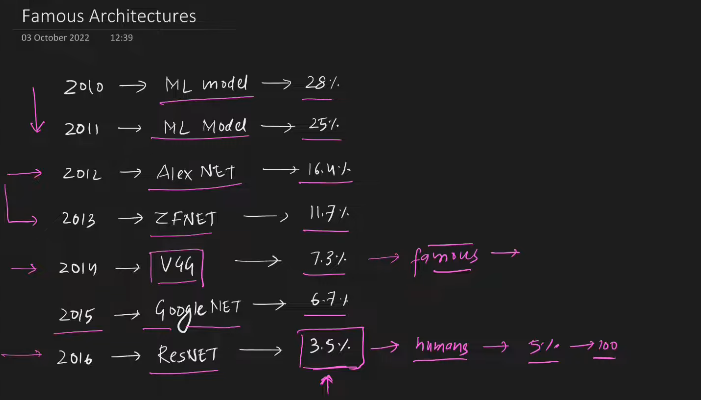



---

## 🏆 Top 5 Models (For Beginners to Intermediate)

| Model | Best For | Difficulty |
|------|---------|------------|
| 1. **VGG16** | Image classification, transfer learning | 🟢 Easy |
| 2. **ResNet50** | Strong accuracy, widely used | 🟡 Medium |
| 3. **MobileNetV2** | Fast, for phones & apps | 🟢 Easy |
| 4. **InceptionV3** | Smart architecture, high accuracy | 🟡 Medium |
| 5. **EfficientNetB0** | Best speed/accuracy balance | 🟡 Medium |

Let’s go one by one.

---

## 1. 🖼️ VGG16

### 🔍 How It Works:
- Made by Oxford (2014)
- Super simple: **only 3x3 convolutions** stacked
- 16 layers deep → "VGG16"
- Very clean design → great for learning

> ✅ Think: "CNN, but deeper and repeated"

### ✅ Why Use It?
- Easy to understand
- Great for **transfer learning**
- Works well on small datasets

### 💡 Project Ideas (You Can Do Now):
1. **Cat vs Dog Classifier**  
   - Use `VGG16` + your CNN head  
   - Train on 1,000 images → 95%+ accuracy

2. **Flower Species Recognition**  
   - Use `image_dataset_from_directory`  
   - Fine-tune last layer

3. **Art Style Classifier** (Monet vs Van Gogh)  
   - Fun, creative, works with small data

### 🧩 Code Snippet:
```python
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Sequential, layers

base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
base.trainable = False

model = Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(5, activation='softmax')  # 5 flower types
])
```

---

## 2. 🔁 ResNet50 (Residual Network)

### 🔍 How It Works:
- Introduced **skip connections** (a.k.a. "residual blocks")
- Solves **vanishing gradient** in deep nets
- Can be 100+ layers deep

> 🧠 Idea: "If I can’t learn new info, just pass old data forward"

### ✅ Why Use It?
- Very accurate
- Industry standard
- Great for **medical imaging**, **object detection**

### 💡 Project Ideas:
1. **Pneumonia Detection from X-rays**  
   - Use Chest X-Ray dataset (Kaggle)  
   - ResNet learns subtle patterns

2. **Skin Cancer Classifier** (Benign vs Malignant)  
   - Real-world impact

3. **Logo Detection** (Nike, Apple, etc.)  
   - Train on 10 logo classes

### 🧩 Code Snippet:
```python
from tensorflow.keras.applications import ResNet50

base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
```

> Same pattern as VGG — just swap the name!

---

## 3. 📱 MobileNetV2

### 🔍 How It Works:
- Designed for **phones**, **edge devices**
- Super **fast and small**
- Uses **depthwise separable convolutions** (fancy, but efficient)

> ✅ Think: "Lightweight CNN — runs on your phone"

### ✅ Why Use It?
- Perfect for **real-time apps**
- Great for **web or mobile deployment**
- Low power, fast inference

### 💡 Project Ideas:
1. **Real-Time Emotion Detector** (Happy, Sad, Angry)  
   - Use webcam + OpenCV + MobileNet  
   - Deploy as a web app

2. **Plant Disease Detector**  
   - Take photo of leaf → classify disease  
   - Useful for farmers

3. **Hand Gesture Recognizer**  
   - Control a game with hand signs

### 🧩 Code Snippet:
```python
from tensorflow.keras.applications import MobileNetV2

base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
```

> Again — same code, just change model name!

---

## 4. 🔍 InceptionV3

### 🔍 How It Works:
- Uses **multiple filter sizes at once** (1x1, 3x3, 5x5)
- "Inception module" → parallel paths
- Smart: uses **1x1 convs to reduce channels** (bottleneck)

> 🧠 Idea: "Don’t guess which filter size works — try all!"

### ✅ Why Use It?
- High accuracy
- Used in early Google products
- Great for **fine-grained classification**

### 💡 Project Ideas:
1. **Bird Species Classifier**  
   - 200+ bird types — small differences  
   - Inception excels here

2. **Car Model Recognizer** (Honda Civic vs Accord)  
   - Subtle shape differences

3. **Food Classifier** (Pizza vs Burger vs Sushi)  
   - Fun, visual, works well

### 🧩 Code Snippet:
```python
from tensorflow.keras.applications import InceptionV3

base = InceptionV3(weights='imagenet', include_top=False, input_shape=(299,299,3))
```

> ⚠️ Note: Inception uses **299x299**, not 224x224

---

## 5. ⚡ EfficientNetB0

### 🔍 How It Works:
- Google’s **best balance** of speed & accuracy
- Scales **width, depth, resolution** together
- One model, many versions (B0 to B7)

> ✅ Think: "Smarter scaling, not just bigger"

### ✅ Why Use It?
- **Best accuracy per parameter**
- Used in production (Google, startups)
- Future-proof

### 💡 Project Ideas:
1. **Trash Classification** (Plastic, Paper, Metal)  
   - Help recycling bots  
   - Use EfficientNet + Raspberry Pi

2. **AI Art vs Real Art Detector**  
   - With AI art booming, this is useful

3. **Wildlife Camera Trap Classifier**  
   - Detect deer, fox, rabbit from forest cams

### 🧩 Code Snippet:
```python
from tensorflow.keras.applications import EfficientNetB0

base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224,224,3))
```

---

## ✅ Summary: All Models Use Same Pattern

```python
# Step 1: Load pretrained base
base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))

# Step 2: Freeze base
base.trainable = False

# Step 3: Add your head
model = Sequential([
    base,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])
```

🔁 Just change the model name → you can use **any** of the 5!

---

## 🧭 What Should You Learn Next?

| If You Want... | Learn This Model |
|---------------|------------------|
| 🔹 Easy start | VGG16 |
| 🔹 High accuracy | ResNet50 |
| 🔹 Mobile apps | MobileNetV2 |
| 🔹 Fine details | InceptionV3 |
| 🔹 Best overall | EfficientNetB0 |

---

## 🎯 Final Tip: Your Superpower

> You don’t need to build models from scratch.  
> **Use pretrained models + your CNN head** → solve real problems fast.

This is how **90% of real AI projects** are built.

---



#let's code

In [5]:
import tensorflow as tf

base_model = tf.keras.applications.MobileNetV2(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)

)

base_model.trainable  = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),  # compress to 1 vector
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Load and resize data
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Resize from 32x32 → 224x224 (required by MobileNet)
x_train = tf.image.resize(x_train, (224, 224))
x_test = tf.image.resize(x_test, (224, 224))

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Train
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))



---

#### **Q1: What is a pretrained model?**

> "A pretrained model is a deep neural network that has already been trained on a large dataset — like ImageNet — to recognize thousands of objects.  
>
> Instead of training from scratch, we reuse this model as a starting point and adapt it to our own task. It saves time, data, and compute."

---

#### **Q2: Why do we use pretrained models instead of training from scratch?**

> "Training from scratch requires millions of labeled images and weeks of GPU time — which most of us don’t have.  
>
> Pretrained models already know how to detect edges, textures, and shapes from ImageNet. We just fine-tune them on our smaller dataset — which gives better accuracy faster and reduces overfitting."

---

#### **Q3: How does transfer learning work with pretrained models?**

> "Transfer learning means **reusing knowledge** from one task to another.  
>
> For example, I take a pretrained model like MobileNet, freeze its convolutional layers (they’ve learned general features), and replace the final layer with a new one for my task — like cat vs dog.  
>
> Then I train only the new layers. This way, I get strong performance even with just a few hundred images."

---

#### **Q4: Can you name a few popular pretrained models?**

> "Sure:
>
> - **VGG16**: Simple, easy to understand — good for learning.
> - **ResNet50**: Uses skip connections — very deep, very accurate.
> - **MobileNetV2**: Lightweight — runs on phones and edge devices.
> - **EfficientNetB0**: Best accuracy per parameter — great for production.
> - **InceptionV3**: Uses parallel filters — good for fine details.
>
> I usually start with MobileNet or EfficientNet for real projects."

---

#### **Q5: How do you load a pretrained model in Keras?**

> "Very simply:
>
> ```python
> base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
> base.trainable = False
> ```
>
> `weights='imagenet'` loads the pretrained weights. `include_top=False` removes the final classifier so I can add my own."

---

#### **Q6: What does `weights='imagenet'` mean?**

> "It means the model is pre-trained on the **ImageNet dataset** — which has 1.2 million images across 1000 classes.  
>
> So the model already knows how to recognize things like dogs, cars, and flowers. I don’t start from zero — I start from what it already learned."

---

#### **Q7: When would you fine-tune the pretrained base?**

> "After training the new classifier head, I sometimes **unfreeze the top few layers** of the base and train with a **very low learning rate**.  
>
> This is called **fine-tuning**. It helps the model adapt better — especially if my data is different from ImageNet, like medical images or satellite photos."

---

#### **Q8: Should you always use a pretrained model?**

> "No — not always.  
>
> If I have a **huge dataset** (like millions of domain-specific images), training from scratch might be better.  
>
> Or if the data is very different — like audio or text — I’d use a model pretrained on that modality instead.  
>
> But for most image tasks with limited data, pretrained models are the best choice."

---

#### **Q9: What are the risks of using pretrained models?**

> "Two main risks:
>
> 1. **Domain mismatch**: A model trained on natural images may not work well on X-rays or sketches.
> 2. **Overfitting the head**: If I don’t regularize the new layers, the model memorizes small data.
>
> To avoid this, I use data augmentation, dropout, and fine-tune carefully."

---

#### **Q10: How do you evaluate a pretrained model on a new task?**

> "I split my data into train, validation, and test sets.  
>
> I train only the classifier head first, then optionally fine-tune.  
>
> I evaluate on the **test set only once** — to get an honest measure of performance.  
>
> I also check confusion matrix and look at misclassified images to understand model behavior."

---

#### **Q11: Can you use pretrained models for small datasets?**

> "Yes — that’s exactly where they shine.  
>
> With just 500–1000 images, a pretrained model can reach 90%+ accuracy, while training from scratch might fail.  
>
> I’ve used MobileNet on small datasets like plant disease or logo detection — works great with augmentation."

---

#### **Q12: What’s the difference between feature extraction and fine-tuning?**

> "Great question.
>
> - **Feature extraction**: I freeze the entire pretrained base and train only the new classifier head. Fast and safe.
> - **Fine-tuning**: After training the head, I unfreeze some top layers of the base and train everything with a low learning rate. Makes the model adapt better.
>
> I always do feature extraction first, then fine-tune if needed."

---

## ✅ Final Tip (For You)

>
>
> _"I use pretrained models like MobileNet or EfficientNet with transfer learning — freeze the base, add a simple head, train, and optionally fine-tune."_
>
> This shows you know **modern best practices**.

---

